# Enunciado 1;

### Dataset

1. Faça o download do dataset:
  - Opção 1: https://www.tensorflow.org/datasets/catalog/cifar10_corrupted?hl=pt-br (uma das opções de corrompimento).
  - Opção 2: https://www.tensorflow.org/datasets/catalog/rock_paper_scissors?hl=pt-br.
  - Opção 3: https://www.tensorflow.org/datasets/catalog/beans?hl=pt-br 
  - Opção 4: https://www.tensorflow.org/datasets/catalog/malaria?hl=pt-br 
  - Opção 5: https://www.tensorflow.org/datasets/catalog/eurosat?hl=pt-br
2. Adicione ruído do tipo salt and pepper, branco ou gaussino. Caso escolha a Opção 1, não é necessário aplicar ruído.
3. Dimensione o dataset para uma quantidade adequada de imagens que seja possível treinar e testar (principalmente se você usa o Colab free). Porém, cuidado com um quantidade muito pequena que não possibilite uma boa generalização de amostras.
4. Faça o split do dataset em uma quantidade adequada para treinamento, validação e teste. É extremamente desejavel um nível bom de aleatoriedade ao fazer o split dos dados.


# Pipeline de Aplicação de Redes Neural Convolucional

### Dataset Selecionado: Rock, Paper  and Scissors. [LINK](https://www.tensorflow.org/datasets/catalog/rock_paper_scissors?hl=pt-br)



*deletar o .claude antes de subir p git





In [2]:
from main import *
from pre_processing import *
import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


%load_ext autoreload
%autoreload 2


main()

I0000 00:00:1782761220.564879    3308 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782761220.571224    3308 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782761221.250634    3308 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782761226.352002    3308 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

---main---


### Inicilizando o DataSet

[doc tfds](https://github.com/tensorflow/datasets/blob/master/README.md)


alterar o ds_size, para o tamanho (teste de pré-processamento)

E0000 00:00:1782761230.756521    3308 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
I0000 00:00:1782761231.296353   18207 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
W0000 00:00:1782761233.410926   18210 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


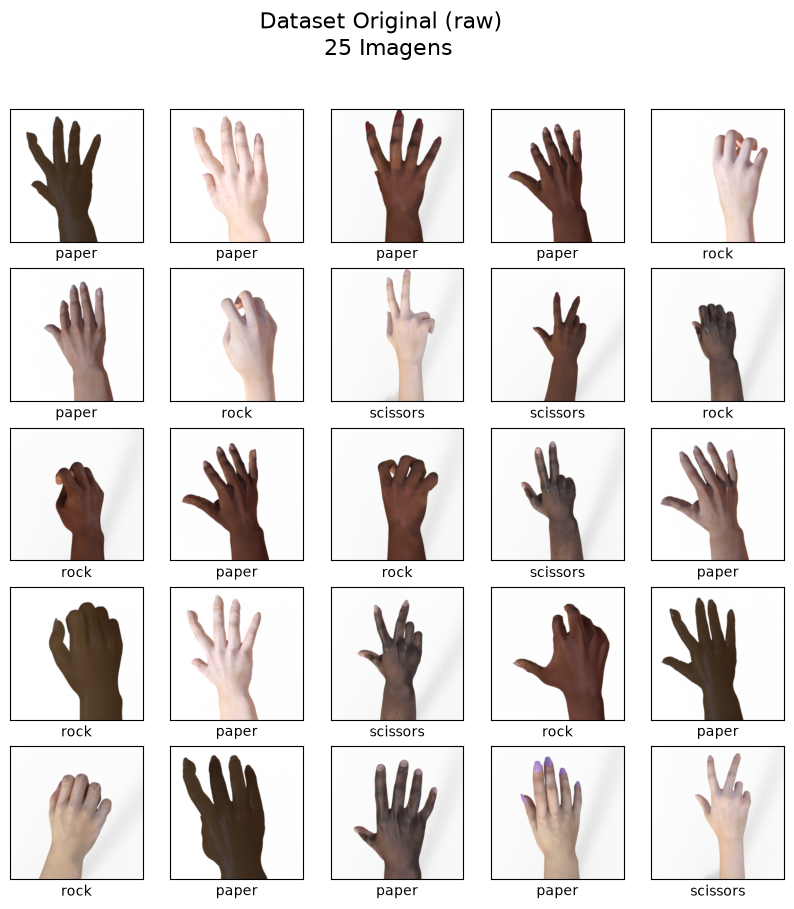

In [3]:
dataset_train, dataset_test =  generate_dataset()

ds_size = 25

ds_raw = dataset_train.shuffle(1000).take(ds_size)

label_names = ['rock', 'paper' , 'scissors']


#fig, axes = plt.subplots(1, ds_size, figsize=(15 + ds_size, 4*ds_size))

plt.figure(figsize=(10,10))


for idx, (img_raw, img_label_i) in enumerate(ds_raw):
    
    label_str = label_names[img_label_i.numpy()]

    plt.subplot(5,5, idx+1)
    

    plt.imshow(img_raw)
    plt.xlabel(label_str)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    

    
plt.suptitle(f"Dataset Original (raw) \n {ds_size} Imagens", fontsize=16)

plt.show()

W0000 00:00:1782761241.320018   18323 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


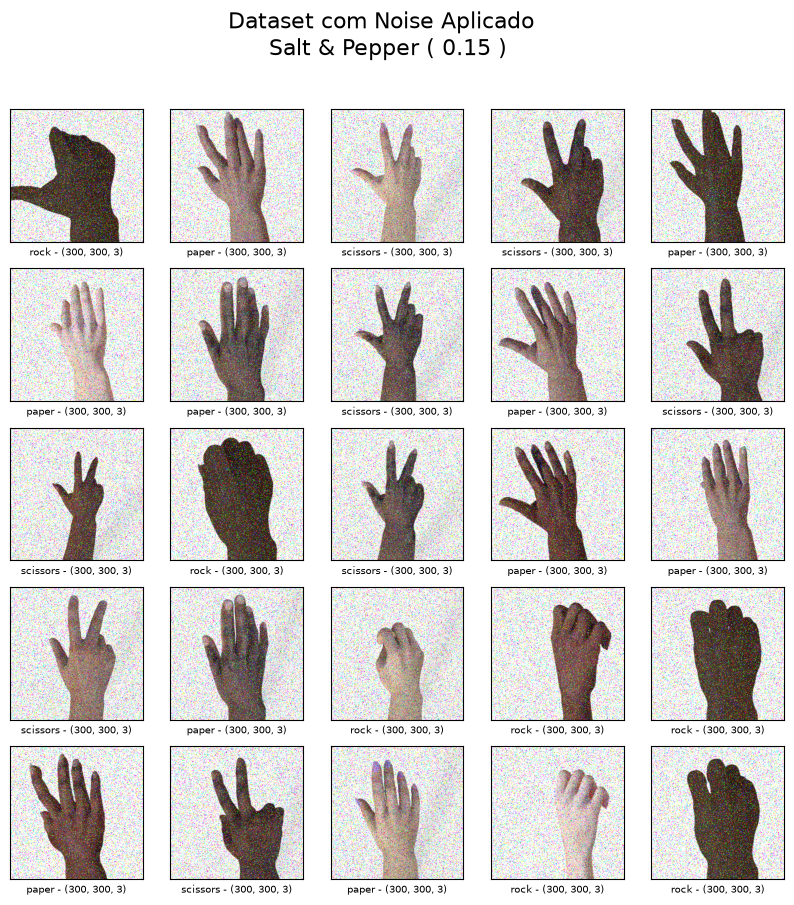

In [4]:
plt.figure(figsize=(10,10))

ds_preprocess = []
for idx, (img_raw, img_label_i) in enumerate(ds_raw):
    
    label_str = label_names[img_label_i.numpy()]

    plt.subplot(5,5, idx+1)
    
    p_img = apply_salt_pepper(img_raw)
    ds_preprocess.append(p_img)
    plt.imshow(p_img)
    plt.xlabel(f"{label_str} - {p_img.shape}", fontsize=7)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    

    
plt.suptitle("Dataset com Noise Aplicado \n Salt & Pepper ( 0.15 )", fontsize=16)
plt.show()

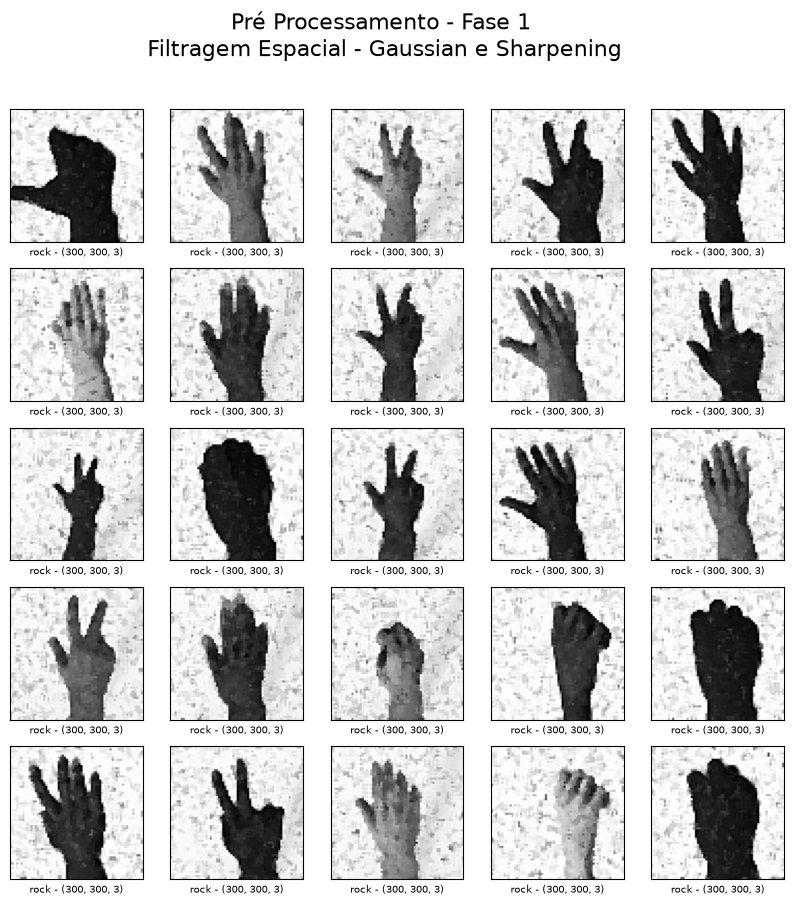

In [5]:
plt.figure(figsize=(10,10))

ds_filtrado = []

for idx in range(len(ds_preprocess)):
    ## label cagada pq to puxando do array e nao do tfds
    label_str = label_names[img_label_i.numpy()]

    plt.subplot(5,5, idx+1)
    
    img_filtrada = pipe_filtragem_espacial(ds_preprocess[idx])

    ds_filtrado.append(img_filtrada)
    plt.imshow(img_filtrada, cmap='gray')
    plt.xlabel(f"{label_str} - {p_img.shape}", fontsize=7)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    

    
plt.suptitle("Pré Processamento - Fase 1 \n Filtragem Espacial - Gaussian e Sharpening ", fontsize=16)
plt.show()

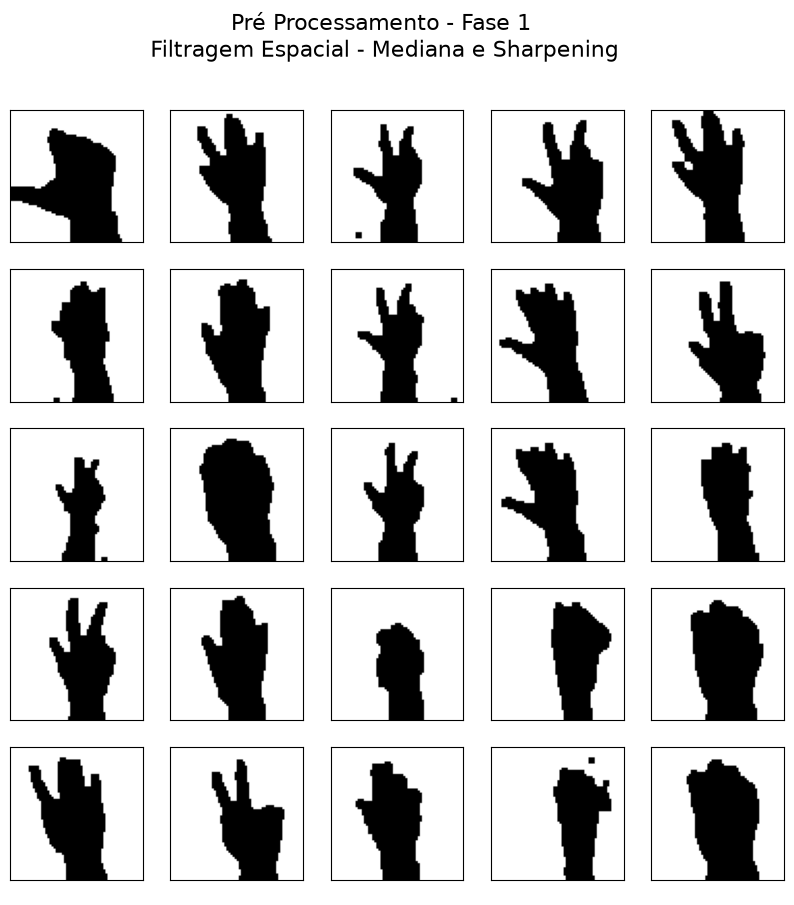

In [6]:
plt.figure(figsize=(10,10))

ds_morf = []

for idx in range(len(ds_filtrado)):
    ## label cagada pq to puxando do array e nao do tfds
    label_str = label_names[img_label_i.numpy()]

    plt.subplot(5,5, idx+1)
    
    img_morfed = pipe_morfologia(ds_filtrado[idx])

    ds_morf.append(img_morfed)
    plt.imshow(img_morfed, cmap='gray')
    plt.xlabel(f" ", fontsize=7)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    

    
plt.suptitle("Pré Processamento - Fase 1 \n Filtragem Espacial - Mediana e Sharpening ", fontsize=16)
plt.show()

# Final do pre-processamento


### fase 1
salt&pepper -> 
### fase 2
resize 64 -> normalize (tf nativo) -> grayscale (tf nativo) -> median (cv2 nativo) → gamma 1.5 (m1) → sharpening 1.0 (m1 com conv2d )
### fase 3 
moforlogia (m2) [  threshold dinamico (limiar) → abertura → fechamento ]

troquei para funcoes do cv2 devido a demora para processar com looping manual


### Teste do .map() - LAZYYY


aplica no dataset o .map() com a pipeline anterior

In [7]:
ds_train_pronto = dataset_train.map(pipeline_preProcessing)

ds_test_pronto = dataset_test.map(pipeline_preProcessing)

W0000 00:00:1782761562.093048   20738 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


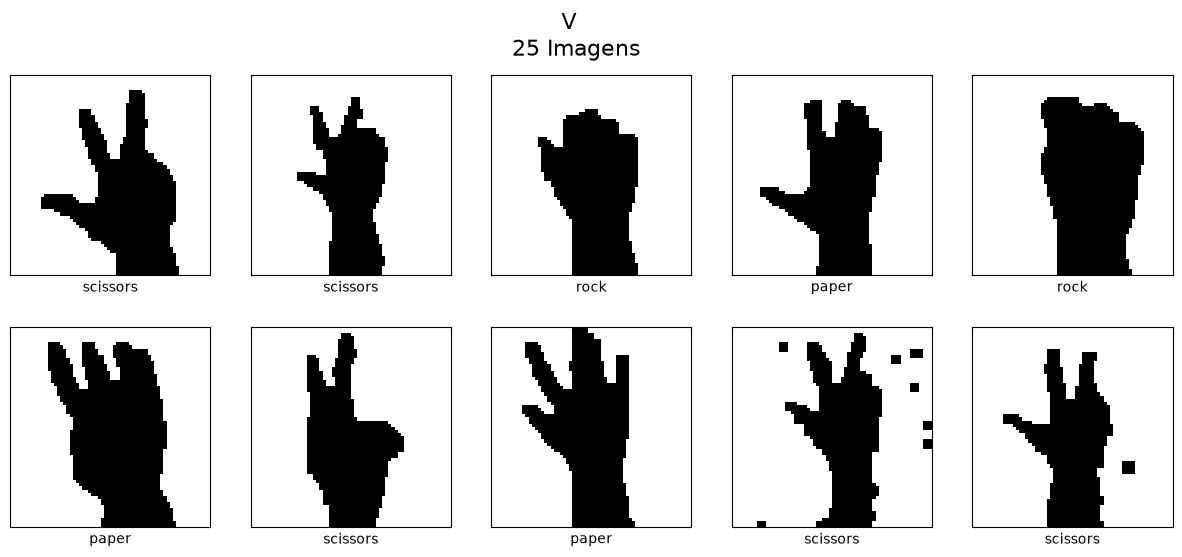

In [ ]:
plt.figure(figsize=(15,6))


for idx, (img, img_label_i) in enumerate(ds_train_pronto.take(10)):
    print 
    label_str = label_names[img_label_i.numpy()]

    plt.subplot(2,5, idx+1)
    

    plt.imshow(img, cmap='gray')
    plt.xlabel(label_str)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    

    
plt.suptitle(f"Validação do Dataset antes de treinar \n {ds_size} Imagens", fontsize=16)

plt.show()

## Inicio da CNN - Base - Criação do Modelo

In [ ]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64,64, 1)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64, (3,3), activation='relu'))


##Camadas densas
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.4)) ## teste
model.add(layers.Dense(3, activation='softmax')) 


model.summary()

/home/alex/Desktop/Projeto_M3/pdi_m3/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 645,827 (2.46 MB)

 Trainable params: 645,827 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

### Compilação do Modelo



In [15]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy']
              )


In [19]:

#ds_train_final = ds_train_pronto.cache().batch(32).prefetch(tf.data.AUTOTUNE)
#ds_test_final  = ds_test_pronto.cache().batch(32).prefetch(tf.data.AUTOTUNE)


ds_train_final = ds_train_pronto.batch(32).prefetch(tf.data.AUTOTUNE)
ds_test_final  = ds_test_pronto.batch(32).prefetch(tf.data.AUTOTUNE)


history = model.fit(
    ds_train_final,
    epochs=7,
    validation_data=ds_test_final,   # sem batch_size aqui!
)

Epoch 1/7


/home/alex/Desktop/Projeto_M3/pdi_m3/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


79/79 ━━━━━━━━━━━━━━━━━━━━ 51s 641ms/step - accuracy: 0.9992 - loss: 0.0056 - val_accuracy: 0.7715 - val_loss: 1.0998
Epoch 2/7
79/79 ━━━━━━━━━━━━━━━━━━━━ 50s 636ms/step - accuracy: 0.9996 - loss: 0.0014 - val_accuracy: 0.7446 - val_loss: 2.2461
Epoch 3/7
79/79 ━━━━━━━━━━━━━━━━━━━━ 50s 636ms/step - accuracy: 0.9996 - loss: 7.2975e-04 - val_accuracy: 0.7608 - val_loss: 2.1794
Epoch 4/7
79/79 ━━━━━━━━━━━━━━━━━━━━ 50s 635ms/step - accuracy: 1.0000 - loss: 3.1221e-04 - val_accuracy: 0.7634 - val_loss: 2.3599
Epoch 5/7
79/79 ━━━━━━━━━━━━━━━━━━━━ 50s 636ms/step - accuracy: 1.0000 - loss: 1.6156e-04 - val_accuracy: 0.7715 - val_loss: 1.9833
Epoch 6/7
79/79 ━━━━━━━━━━━━━━━━━━━━ 50s 633ms/step - accuracy: 0.9996 - loss: 5.2532e-04 - val_accuracy: 0.8038 - val_loss: 1.5385
Epoch 7/7
79/79 ━━━━━━━━━━━━━━━━━━━━ 51s 644ms/step - accuracy: 0.9992 - loss: 0.0033 - val_accuracy: 0.7984 - val_loss: 1.4037


In [23]:
print(test_acc)

0.8118279576301575


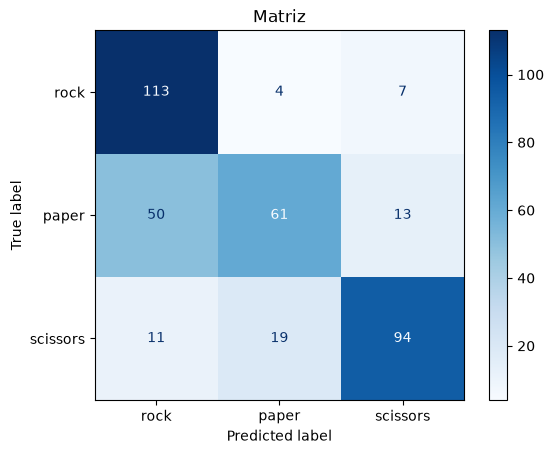

In [18]:
y_true, y_pred = [], []
for imgs, labels in ds_test_final:
    preds = model.predict(imgs, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))   # classe prevista
    y_true.extend(labels.numpy())             # classe real

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap='Blues')
plt.title('Matriz')
plt.show()

### Observações

- A pipeline CNN sugerida, funcinou legal. porém o dataset utilizado não havia uma grande quantidade de imagens. Acabou que deu overlifiting
--- Mesmo com dropout, não conseguimos resolver. talvez outras tecnicas de ex, 'earlystopping' pode ajuda a se obter melhores resultados

- O modelo teve bastante dificuldade para classificar o 'papel', por conta da silueta gerada pela Morfologia
--- A dificuldade está em acertar o algoritmo para não perder os detalhes do dedos, principalmente quando é 'tesoura' e quando a mão é muito branca

- O tempo de processamento diminuiu bastante após a implementação das tecnicas: .Map(), .cache() e a troca de looping nativos do python por funções de libs (cv2 e tensorflow)


- De todo modo, os resultados não foram satisfatórios, 